## Extended Analysis

This notebook investigates the boundaries and robustness of the main evaluation results from Notebook 3. Four analyses are conducted: error analysis with confusion matrix breakdown, text length and truncation analysis, a chunking strategy experiment, and a boilerplate removal test. None of these analyses change the main results. They deepen the understanding of why LaBSE performs as it does, where its limits lie, and what practical implications follow for the AI Curriculum Tool project.

All reference values (thresholds, baseline F1 values) are loaded from the CSVs produced by Notebook 3 so that this notebook stays in sync when Notebook 3 is re-run. Bootstrap 95 percent confidence intervals are attached to every reported F1, matching the uncertainty quantification used in Notebooks 3 and 4.

### Imports and Setup

In [1]:
import sys
import random
import warnings
from pathlib import Path
from importlib.metadata import version
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from transformers import logging as hf_logging
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score, confusion_matrix,
)

import re
import spacy

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sentence_transformers")
hf_logging.set_verbosity_error()

print(f"Python               : {sys.version.split()[0]}")
print(f"torch                : {torch.__version__}")
print(f"transformers         : {version('transformers')}")
print(f"sentence-transformers: {version('sentence-transformers')}")
print(f"numpy                : {np.__version__}")
print(f"pandas               : {pd.__version__}")
print(f"sklearn              : {version('scikit-learn')}")
print(f"spaCy                : {spacy.__version__}")

Python               : 3.10.20
torch                : 2.12.0.dev20260408+cu128
transformers         : 5.4.0
sentence-transformers: 5.3.0
numpy                : 2.2.6
pandas               : 2.3.3
sklearn              : 1.7.2
spaCy                : 3.8.14


### Project Paths

All paths are derived from the notebook's working directory, matching the pattern used in all other notebooks in this pipeline.

In [2]:
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
EMBEDDINGS_DIR = DATA_DIR / "embeddings" / "ict"
RESULTS_DIR = DATA_DIR / "results"
SUMMARY_DIR = RESULTS_DIR / "summary_tables"
EXTENDED_DIR = RESULTS_DIR / "extended_analysis"
FIGURES_DIR = PROJECT_ROOT / "figures" / "main"

EXTENDED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Processed    : {PROCESSED_DIR}")
print(f"Embeddings   : {EMBEDDINGS_DIR}")
print(f"Results      : {RESULTS_DIR}")
print(f"Figures      : {FIGURES_DIR}")

Project root : c:\Users\madee\OneDrive\Desktop\thesis
Processed    : c:\Users\madee\OneDrive\Desktop\thesis\data\processed
Embeddings   : c:\Users\madee\OneDrive\Desktop\thesis\data\embeddings\ict
Results      : c:\Users\madee\OneDrive\Desktop\thesis\data\results
Figures      : c:\Users\madee\OneDrive\Desktop\thesis\figures\main


### Loading Dataset and Reference Values

The preprocessed dataset and all reference values from Notebook 3 are loaded at runtime. The threshold used for all LaBSE evaluations in this notebook is the mean cross-validation threshold from Notebook 3, not the in-sample optimum, which is the more honest operating point for a generalisation-focused analysis.

In [3]:
df = pd.read_csv(PROCESSED_DIR / "dataset_preprocessed.csv")
labels = df['similarity_label'].values

print(f"Dataset loaded: {df.shape}")
print(f"Labels        : {dict(zip(*np.unique(labels, return_counts=True)))}")

# Load Notebook 3 reference tables
ict_summary = pd.read_csv(SUMMARY_DIR / "full_evaluation_summary.csv")
ict_cv = pd.read_csv(SUMMARY_DIR / "cv_5fold_results.csv")

labse_summary = ict_summary[ict_summary['model'] == 'labse'].copy()
labse_cv = ict_cv[ict_cv['model'] == 'labse'].copy()

CFG1_NAME = 'Outcomes (Raw)'
CFG3_NAME = 'Outcomes + Contents + Assessment (Raw)'

cfg1_row = labse_summary[labse_summary['config'] == CFG1_NAME].iloc[0]
cfg1_cv_row = labse_cv[labse_cv['config'] == CFG1_NAME].iloc[0]
cfg3_row = labse_summary[labse_summary['config'] == CFG3_NAME].iloc[0]
cfg3_cv_row = labse_cv[labse_cv['config'] == CFG3_NAME].iloc[0]

# Operating threshold: the mean CV threshold from Notebook 3 (honest choice)
THRESHOLD = round(float(cfg1_cv_row['threshold_mean']), 2)

# Reference F1 values
F1_CFG1_INSAMPLE = float(cfg1_row['f1'])
F1_CFG1_INSAMPLE_CI = (float(cfg1_row['f1_ci_low']), float(cfg1_row['f1_ci_high']))
F1_CFG1_CV_MEAN = float(cfg1_cv_row['cv_f1_mean'])
F1_CFG1_CV_STD = float(cfg1_cv_row['cv_f1_std'])

F1_CFG3_INSAMPLE = float(cfg3_row['f1'])
F1_CFG3_CV_MEAN = float(cfg3_cv_row['cv_f1_mean'])
F1_CFG3_CV_STD = float(cfg3_cv_row['cv_f1_std'])

print(f"\nOperating threshold (from CV mean): {THRESHOLD:.2f}")
print(f"\nReference F1 for LaBSE {CFG1_NAME}:")
print(f"  In-sample : {F1_CFG1_INSAMPLE:.3f} [{F1_CFG1_INSAMPLE_CI[0]:.3f}, {F1_CFG1_INSAMPLE_CI[1]:.3f}]")
print(f"  5-fold CV : {F1_CFG1_CV_MEAN:.3f} ± {F1_CFG1_CV_STD:.3f}")
print(f"\nReference F1 for LaBSE {CFG3_NAME}:")
print(f"  In-sample : {F1_CFG3_INSAMPLE:.3f}")
print(f"  5-fold CV : {F1_CFG3_CV_MEAN:.3f} ± {F1_CFG3_CV_STD:.3f}")

Dataset loaded: (154, 33)
Labels        : {np.int64(0): np.int64(77), np.int64(1): np.int64(77)}

Operating threshold (from CV mean): 0.88

Reference F1 for LaBSE Outcomes (Raw):
  In-sample : 0.981 [0.955, 1.000]
  5-fold CV : 0.968 ± 0.022

Reference F1 for LaBSE Outcomes + Contents + Assessment (Raw):
  In-sample : 0.969
  5-fold CV : 0.970 ± 0.030


### Evaluation Helpers

The helpers below are the same as those used in Notebooks 3 and 4: a fixed-threshold evaluator, a percentile-bootstrap F1 CI, and an L2 normalizer with an embedded shape and norm assertion. Reusing the same helpers keeps results comparable across notebooks.

In [4]:
N_BOOTSTRAP = 1000

def evaluate_at_threshold(sim, y_true, threshold):
    preds = (sim >= threshold).astype(int)
    return {
        'precision': precision_score(y_true, preds, zero_division=0),
        'recall'   : recall_score(y_true, preds, zero_division=0),
        'f1'       : f1_score(y_true, preds, zero_division=0),
        'accuracy' : accuracy_score(y_true, preds),
    }

def bootstrap_f1(sim, y_true, threshold, n_iter=N_BOOTSTRAP, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    f1s = []
    for _ in range(n_iter):
        idx = rng.integers(0, n, n)
        yt = y_true[idx]
        if len(np.unique(yt)) < 2:
            continue
        preds = (sim[idx] >= threshold).astype(int)
        f1s.append(f1_score(yt, preds, zero_division=0))
    f1s = np.array(f1s)
    return float(f1s.mean()), float(np.percentile(f1s, 2.5)), float(np.percentile(f1s, 97.5))

def l2_normalize_verified(emb, name=""):
    """L2 normalize an array and assert it came out clean."""
    assert emb.ndim == 2, f"{name}: expected 2D, got shape {emb.shape}"
    assert not np.isnan(emb).any(), f"{name}: NaN in embeddings"
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    emb = emb / np.clip(norms, a_min=1e-10, a_max=None)
    post = np.linalg.norm(emb, axis=1)
    assert np.allclose(post, 1.0, atol=1e-5), (
        f"{name}: L2 normalization failed, range [{post.min():.6f}, {post.max():.6f}]"
    )
    return emb

print("Helpers defined.")

Helpers defined.


## Part 1: Error Analysis

Error analysis examines which pairs LaBSE classified incorrectly on the outcomes-only raw configuration at the operating threshold. Each of the 154 pairs is classified as a true positive, true negative, false positive, or false negative, and the misclassified pairs are then inspected individually to understand which characteristics led to misclassification.

The numbers reported here are in-sample at the fixed threshold. They are useful for qualitative inspection of error modes but should not be confused with the held-out 5-fold CV numbers from Notebook 3, which are the more honest estimates of deployment-time performance.

In [5]:
fi_emb = np.load(EMBEDDINGS_DIR / 'labse_config1_fi.npy')
en_emb = np.load(EMBEDDINGS_DIR / 'labse_config1_en.npy')

# Sanity check
expected = (len(df), 768)
assert fi_emb.shape == expected and en_emb.shape == expected
assert not np.isnan(fi_emb).any() and not np.isnan(en_emb).any()
assert np.allclose(np.linalg.norm(fi_emb, axis=1), 1.0, atol=1e-5)
assert np.allclose(np.linalg.norm(en_emb, axis=1), 1.0, atol=1e-5)

sim_scores = np.sum(fi_emb * en_emb, axis=1)
preds = (sim_scores >= THRESHOLD).astype(int)

cm = confusion_matrix(labels, preds)
tn, fp, fn, tp = cm.ravel()

metrics = evaluate_at_threshold(sim_scores, labels, THRESHOLD)
f1_mean, f1_lo, f1_hi = bootstrap_f1(sim_scores, labels, THRESHOLD)

# Verify in-sample F1 matches the Notebook 3 reference (sanity check on embeddings and threshold)
# Small difference possible if the threshold has shifted from the in-sample optimum
print(f"Confusion matrix at threshold {THRESHOLD}:")
print(f"  True Positives  (TP): {tp}")
print(f"  True Negatives  (TN): {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"\nMetrics at operating threshold:")
print(f"  Precision: {metrics['precision']:.3f}")
print(f"  Recall   : {metrics['recall']:.3f}")
print(f"  F1       : {metrics['f1']:.3f}  95% CI [{f1_lo:.3f}, {f1_hi:.3f}]")
print(f"  Accuracy : {metrics['accuracy']:.3f}")
print(f"\nFor reference (from Notebook 3):")
print(f"  In-sample F1 at best threshold: {F1_CFG1_INSAMPLE:.3f}")
print(f"  5-fold CV F1 mean             : {F1_CFG1_CV_MEAN:.3f} ± {F1_CFG1_CV_STD:.3f}")

df['sim_score'] = sim_scores
df['prediction'] = preds
false_positives = df[(df['similarity_label'] == 0) & (df['prediction'] == 1)]
false_negatives = df[(df['similarity_label'] == 1) & (df['prediction'] == 0)]

print(f"\nFalse positives: {len(false_positives)}")
print(f"False negatives: {len(false_negatives)}")

Confusion matrix at threshold 0.88:
  True Positives  (TP): 75
  True Negatives  (TN): 75
  False Positives (FP): 2
  False Negatives (FN): 2

Metrics at operating threshold:
  Precision: 0.974
  Recall   : 0.974
  F1       : 0.974  95% CI [0.947, 0.994]
  Accuracy : 0.974

For reference (from Notebook 3):
  In-sample F1 at best threshold: 0.981
  5-fold CV F1 mean             : 0.968 ± 0.022

False positives: 2
False negatives: 2


### Inspecting the False Positives

Below, each false positive is printed with its course identifier, pair type, similarity score, and outcomes text. The purpose is qualitative: to understand whether the errors reflect genuine ambiguity in the data (thematically adjacent courses) or model weakness (failure to distinguish clearly different content).

In [6]:
if len(false_positives) == 0:
    print("No false positives at this threshold.")
else:
    print("False Positive Pairs:\n")
    for i, row in false_positives.iterrows():
        print(f"Pair index     : {i}")
        print(f"Course ID      : {row['course_id']}")
        print(f"Pair type      : {row['pair_type']}")
        print(f"Pair difficulty: {row['pair_difficulty']}")
        print(f"Similarity     : {row['sim_score']:.4f}")
        print(f"Finnish outcomes: {row['outcomes_fi'][:300]}")
        print(f"English outcomes: {row['outcomes_en'][:300]}")
        print("-" * 80)

False Positive Pairs:

Pair index     : 74
Course ID      : SYN_HARD_TT00CQ78_TT00CQ80
Pair type      : constructed
Pair difficulty: hard_negative
Similarity     : 0.8836
Finnish outcomes: Sinä hallitset keskeisimmät kyberturvallisuuteen liittyvät osa-alueet: kyberturvallisuuden nykytila, kyberturvallisuusuhat, terminologia ja informaatiovaikuttaminen. Sinä käsität miten nämä soveltuvat henkilökohtaisessa, yhteiskunnallisessa ja organisaation kyberturvallisuudessa. Sinä tunnet tiedons
English outcomes: You will have a good understanding of the key aspects of cybersecurity and information security and how to apply them in practice. You will understand how these apply to personal, societal and organisational cyber and information security. You will be familiar with technical methods to protect syste
--------------------------------------------------------------------------------
Pair index     : 128
Course ID      : SYN_HARD_TT00CQ78_TT00CD86
Pair type      : constructed
Pair difficulty:

In [7]:
if len(false_negatives) == 0:
    print("No false negatives at this threshold (in-sample).")
    print("Note: CV results from Notebook 3 may include false negatives on held-out folds.")
    print(f"CV recall (mean across 5 folds): see cv_5fold_results.csv")
else:
    print("False Negative Pairs:\n")
    for i, row in false_negatives.iterrows():
        print(f"Pair index     : {i}")
        print(f"Course ID      : {row['course_id']}")
        print(f"Pair type      : {row['pair_type']}")
        print(f"Similarity     : {row['sim_score']:.4f}")
        print(f"Finnish outcomes: {row['outcomes_fi'][:300]}")
        print(f"English outcomes: {row['outcomes_en'][:300]}")
        print("-" * 80)

False Negative Pairs:

Pair index     : 49
Course ID      : TZLM3300
Pair type      : real
Similarity     : 0.8709
Finnish outcomes: Opintojakson tarkoitus Käytyäsi tämän opintojakson hallitset muutosilmiöiden tarkastelussa tarvittavia työkaluja. Muutoksen matemaattinen tarkastelu edellyttää derivaatan ja integraalin käsitteitä. Tällä opintojaksolla opit nämä käsitteet sekä niiden soveltamista. Opintojakson osaamiset EUR-ACE: Tie
English outcomes: The object of the course During this course you will learn the concepts needed to study continuous change and dynamic phenomena. With differential calculus you can study instantaneous rates of change and the slopes of curves. With integral calculus you can study accumulation of quantities and areas 
--------------------------------------------------------------------------------
Pair index     : 70
Course ID      : TT00CD91
Pair type      : real
Similarity     : 0.8790
Finnish outcomes: Osaat suunnitella ja dokumentoida luokkia ja olioita sek

The false-positive pairs visible above are thematically adjacent hard negatives drawn from the same subject domain. In each case the model assigns high similarity because the two courses genuinely cover overlapping topics and use similar terminology. These misclassifications reflect the inherent difficulty of distinguishing between thematically related but non-equivalent courses, which is precisely what makes constructed hard negatives challenging by design.

An important caveat: the "no false negatives" claim is an in-sample property at the operating threshold chosen to maximize F1 on this dataset. The held-out cross-validation results from Notebook 3 should be consulted for the honest deployment-time recall estimate, because perfect recall at one threshold on one dataset does not imply perfect recall on unseen data.

### Confusion Matrix Visualisation

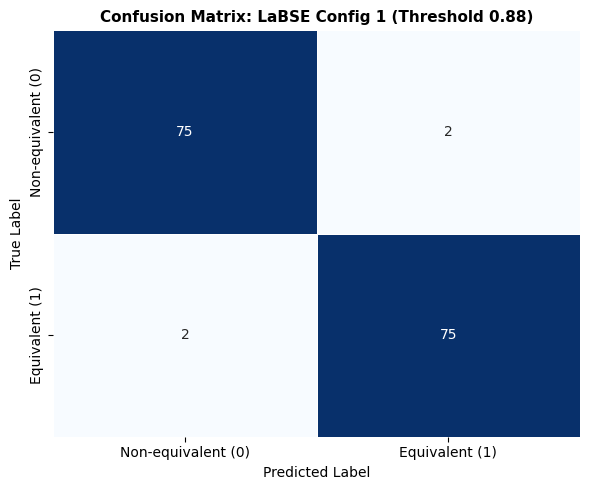

Plot saved: c:\Users\madee\OneDrive\Desktop\thesis\figures\main\confusion_matrix_labse.png


In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

cm_display = np.array([[tn, fp], [fn, tp]])
cm_labels = ['Non-equivalent (0)', 'Equivalent (1)']

sns.heatmap(
    cm_display, annot=True, fmt='d', cmap='Blues',
    xticklabels=cm_labels, yticklabels=cm_labels,
    linewidths=0.5, linecolor='white', ax=ax, cbar=False,
)
ax.set_title(f'Confusion Matrix: LaBSE Config 1 (Threshold {THRESHOLD:.2f})',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

plt.tight_layout()
plot_path = FIGURES_DIR / 'confusion_matrix_labse.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

## Part 2: Text Length and Truncation Analysis

Transformer sentence embedding models process text up to a maximum of 512 subword tokens. Configurations that combine multiple fields may exceed this limit, meaning the model sees only a truncated version of the full text. This analysis measures the subword-token length distribution across all six configurations using the LaBSE tokenizer, quantifies how much truncation occurs, and connects the truncation rate to the evaluation results from Notebook 3.

If Notebook 2 has already produced `truncation_report.csv`, that table is used directly for consistency. Otherwise the values are computed here from scratch.

In [9]:
truncation_report_path = PROCESSED_DIR / "truncation_report.csv"

if truncation_report_path.exists():
    trunc_full = pd.read_csv(truncation_report_path)
    # Filter to LaBSE only and aggregate to Notebook 5's presentation format
    trunc_labse = trunc_full[trunc_full['model'] == 'labse'].copy()
    print(f"Loaded truncation report from Notebook 2: {len(trunc_labse)} rows for LaBSE")

    config_label_map = {
        1: 'Config 1 (Raw)', 2: 'Config 2 (Raw)', 3: 'Config 3 (Raw)',
        4: 'Config 4 (Lemma)', 5: 'Config 5 (Lemma)', 6: 'Config 6 (Lemma)',
    }

    rows = []
    for cfg_num in (1, 2, 3, 4, 5, 6):
        fi = trunc_labse[(trunc_labse['config'] == cfg_num) & (trunc_labse['language'] == 'fi')].iloc[0]
        en = trunc_labse[(trunc_labse['config'] == cfg_num) & (trunc_labse['language'] == 'en')].iloc[0]
        rows.append({
            'config'          : config_label_map[cfg_num],
            'fi_mean_tokens'  : round(float(fi['mean_tokens']), 1),
            'en_mean_tokens'  : round(float(en['mean_tokens']), 1),
            'fi_truncated'    : int(fi['n_truncated']),
            'en_truncated'    : int(en['n_truncated']),
            'fi_truncated_pct': round(float(fi['pct_truncated']), 1),
            'en_truncated_pct': round(float(en['pct_truncated']), 1),
        })
    truncation_df = pd.DataFrame(rows)
else:
    print("truncation_report.csv not found, computing from scratch with LaBSE tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/LaBSE')
    config_cols = {
        'Config 1 (Raw)'  : ('config_1_fi', 'config_1_en'),
        'Config 2 (Raw)'  : ('config_2_fi', 'config_2_en'),
        'Config 3 (Raw)'  : ('config_3_fi', 'config_3_en'),
        'Config 4 (Lemma)': ('config_4_fi', 'config_4_en'),
        'Config 5 (Lemma)': ('config_5_fi', 'config_5_en'),
        'Config 6 (Lemma)': ('config_6_fi', 'config_6_en'),
    }
    rows = []
    for cfg_name, (fi_col, en_col) in config_cols.items():
        fi_len = df[fi_col].apply(lambda x: len(tokenizer.encode(x, truncation=False)))
        en_len = df[en_col].apply(lambda x: len(tokenizer.encode(x, truncation=False)))
        rows.append({
            'config'          : cfg_name,
            'fi_mean_tokens'  : round(fi_len.mean(), 1),
            'en_mean_tokens'  : round(en_len.mean(), 1),
            'fi_truncated'    : int((fi_len > 512).sum()),
            'en_truncated'    : int((en_len > 512).sum()),
            'fi_truncated_pct': round((fi_len > 512).mean() * 100, 1),
            'en_truncated_pct': round((en_len > 512).mean() * 100, 1),
        })
    truncation_df = pd.DataFrame(rows)

truncation_df.to_csv(EXTENDED_DIR / 'truncation_analysis.csv', index=False)
print("\nToken length and truncation per configuration (LaBSE tokenizer):")
print(truncation_df.to_string(index=False))

Loaded truncation report from Notebook 2: 12 rows for LaBSE

Token length and truncation per configuration (LaBSE tokenizer):
          config  fi_mean_tokens  en_mean_tokens  fi_truncated  en_truncated  fi_truncated_pct  en_truncated_pct
  Config 1 (Raw)           187.9           150.3             0             0               0.0               0.0
  Config 2 (Raw)           374.5           295.3            18             5              11.7               3.2
  Config 3 (Raw)           646.9           537.0           118            75              76.6              48.7
Config 4 (Lemma)           177.6           149.6             0             0               0.0               0.0
Config 5 (Lemma)           351.8           292.9            15             2               9.7               1.3
Config 6 (Lemma)           602.5           531.1            98            75              63.6              48.7


### Truncation Analysis Visualisation

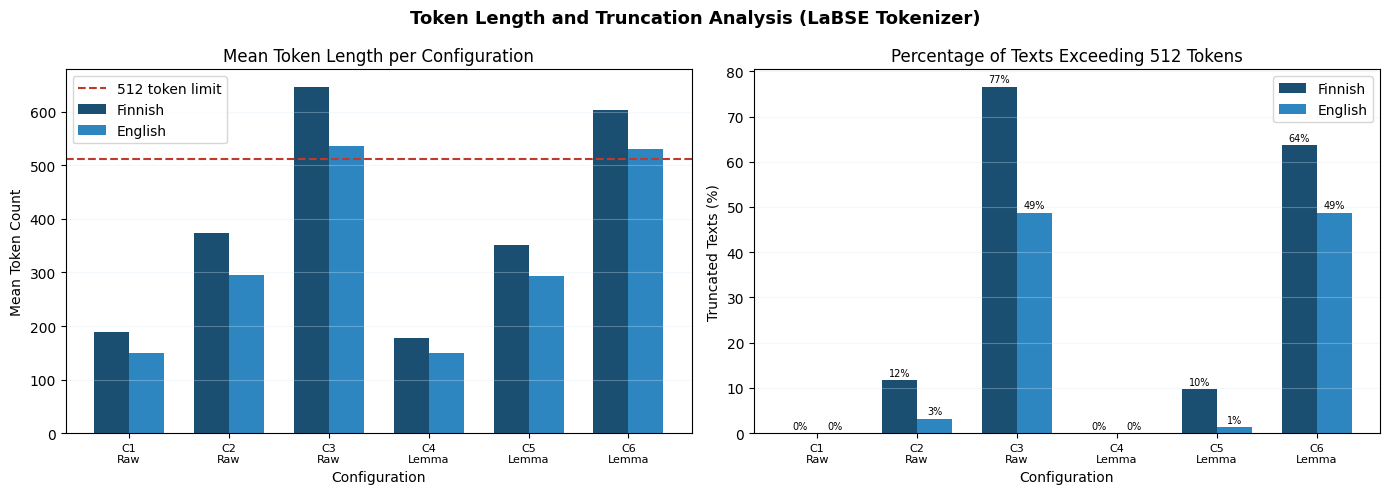

Plot saved: c:\Users\madee\OneDrive\Desktop\thesis\figures\main\truncation_analysis.png


In [10]:
PRIMARY = '#1B4F72'
SECONDARY = '#2E86C1'
POSITIVE = '#1B4F72'
NEGATIVE = '#AAB7B8'
GRID_COLOR = '#D6EAF8'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Token Length and Truncation Analysis (LaBSE Tokenizer)',
             fontsize=13, fontweight='bold')

configs_short = ['C1\nRaw', 'C2\nRaw', 'C3\nRaw', 'C4\nLemma', 'C5\nLemma', 'C6\nLemma']
x = np.arange(len(configs_short))
width = 0.35

ax1 = axes[0]
ax1.bar(x - width/2, truncation_df['fi_mean_tokens'], width,
        label='Finnish', color=PRIMARY)
ax1.bar(x + width/2, truncation_df['en_mean_tokens'], width,
        label='English', color=SECONDARY)
ax1.axhline(y=512, color='#C0392B', linestyle='--', linewidth=1.5, label='512 token limit')
ax1.set_title('Mean Token Length per Configuration')
ax1.set_xlabel('Configuration')
ax1.set_ylabel('Mean Token Count')
ax1.set_xticks(x)
ax1.set_xticklabels(configs_short, fontsize=8)
ax1.legend()
ax1.grid(axis='y', alpha=0.3, color=GRID_COLOR)

ax2 = axes[1]
ax2.bar(x - width/2, truncation_df['fi_truncated_pct'], width,
        label='Finnish', color=PRIMARY)
ax2.bar(x + width/2, truncation_df['en_truncated_pct'], width,
        label='English', color=SECONDARY)
ax2.set_title('Percentage of Texts Exceeding 512 Tokens')
ax2.set_xlabel('Configuration')
ax2.set_ylabel('Truncated Texts (%)')
ax2.set_xticks(x)
ax2.set_xticklabels(configs_short, fontsize=8)
ax2.legend()
ax2.grid(axis='y', alpha=0.3, color=GRID_COLOR)

for i, row in truncation_df.iterrows():
    ax2.text(i - width/2, row['fi_truncated_pct'] + 1.0,
             f"{row['fi_truncated_pct']:.0f}%", ha='center', fontsize=7)
    ax2.text(i + width/2, row['en_truncated_pct'] + 1.0,
             f"{row['en_truncated_pct']:.0f}%", ha='center', fontsize=7)

plt.tight_layout()
plot_path = FIGURES_DIR / 'truncation_analysis.png'
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved: {plot_path}")

The token-length analysis reveals a clear divide between short and long configurations. Configurations 1 and 4 (outcomes only) stay well below the 512-token limit with zero truncation for both languages. Configuration 2 introduces moderate truncation, while configurations 3 and 6 exceed the limit for a majority of Finnish texts. Finnish texts are consistently longer in subword-token count than English despite containing fewer whitespace-separated words, because the LaBSE tokenizer splits morphologically complex Finnish words into more subword pieces. This is a direct empirical reflection of the Finnish morphological density documented by Virtanen et al. (2019).

LaBSE achieves its best F1 on the outcomes-only configuration, which has zero truncation. The comparable or lower F1 on longer configurations that suffer severe truncation suggests that truncation removes discriminative content rather than adding it. The outcomes field alone appears to contain the most semantically concentrated information for equivalence detection, making it both the most computationally efficient and the most accurate configuration.

## Part 3: Chunking Strategy Experiment

One potential remedy for truncation is to split long texts into smaller chunks, embed each chunk separately, and aggregate the resulting vectors. This experiment tests whether a mean-pooled chunking strategy performs better than simple truncation on LaBSE.

To separate the chunking-effect from the truncation-effect, the experiment evaluates both the long configuration (config 3, where truncation is severe) and the short configuration (config 1, where no truncation occurs). Comparing single-encode config 1 to chunked config 1 isolates the chunking-effect alone. Comparing truncated config 3 to chunked config 3 then shows whether chunking recovers any of the information lost to truncation.

Chunk size is set in tokens rather than words, using the LaBSE tokenizer directly. The size of 384 tokens leaves headroom for the `[CLS]` and `[SEP]` special tokens and is close to two-thirds of the 512-token limit, a standard range for overlap-chunked document embedding (Reimers and Gurevych, 2019; Feng et al., 2022). Results are reported with bootstrap 95 percent CIs so that F1 gaps can be interpreted in context.

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

labse = SentenceTransformer('sentence-transformers/LaBSE', device=str(device))
labse.max_seq_length = 512
labse_tokenizer = labse.tokenizer
print(f"LaBSE loaded. max_seq_length = {labse.max_seq_length}")

CHUNK_TOKEN_SIZE = 384
CHUNK_TOKEN_OVERLAP = 64

def token_chunk_encode(texts, model, tokenizer, chunk_size=CHUNK_TOKEN_SIZE,
                       overlap=CHUNK_TOKEN_OVERLAP):
    """Encode texts by splitting long inputs into overlapping token windows
    and mean-pooling the resulting chunk embeddings."""
    stride = chunk_size - overlap
    single_idx, single_texts = [], []
    long_idx, long_chunk_lists = [], []

    for i, text in enumerate(texts):
        ids = tokenizer.encode(text, add_special_tokens=False, truncation=False)
        if len(ids) <= chunk_size:
            single_idx.append(i)
            single_texts.append(text)
        else:
            chunks = []
            start = 0
            while start < len(ids):
                window = ids[start:start + chunk_size]
                chunks.append(tokenizer.decode(window, skip_special_tokens=True))
                if start + chunk_size >= len(ids):
                    break
                start += stride
            long_idx.append(i)
            long_chunk_lists.append(chunks)

    out = np.zeros((len(texts), model.get_sentence_embedding_dimension()),
                   dtype=np.float32)

    if single_texts:
        single_embs = model.encode(single_texts, batch_size=32,
                                   show_progress_bar=False, convert_to_numpy=True)
        for pos, orig_i in enumerate(single_idx):
            out[orig_i] = single_embs[pos]

    for orig_i, chunks in zip(long_idx, long_chunk_lists):
        chunk_embs = model.encode(chunks, batch_size=16,
                                  show_progress_bar=False, convert_to_numpy=True)
        out[orig_i] = chunk_embs.mean(axis=0)
    return out

def run_chunking_trial(config_num):
    """Chunked encoding of a configuration at the operating threshold."""
    fi_col = f'config_{config_num}_fi'
    en_col = f'config_{config_num}_en'
    fi_texts = df[fi_col].tolist()
    en_texts = df[en_col].tolist()

    fi_chunked = token_chunk_encode(fi_texts, labse, labse_tokenizer)
    en_chunked = token_chunk_encode(en_texts, labse, labse_tokenizer)

    fi_chunked = l2_normalize_verified(fi_chunked, f"config_{config_num}_fi chunked")
    en_chunked = l2_normalize_verified(en_chunked, f"config_{config_num}_en chunked")

    sim = np.sum(fi_chunked * en_chunked, axis=1)
    m = evaluate_at_threshold(sim, labels, THRESHOLD)
    f1_mean, f1_lo, f1_hi = bootstrap_f1(sim, labels, THRESHOLD)
    return m, (f1_mean, f1_lo, f1_hi)

def run_single_encode_trial(config_num):
    """Single-encode baseline (simple truncation) at the operating threshold.
    Loads the pre-saved embeddings from Notebook 2 so the comparison against
    the chunked trial differs only in encoding strategy, not in threshold."""
    fi = np.load(EMBEDDINGS_DIR / f'labse_config{config_num}_fi.npy')
    en = np.load(EMBEDDINGS_DIR / f'labse_config{config_num}_en.npy')

    # Reuse the sanity-check discipline from earlier in the notebook
    expected = (len(df), 768)
    assert fi.shape == expected and en.shape == expected
    assert not np.isnan(fi).any() and not np.isnan(en).any()
    assert np.allclose(np.linalg.norm(fi, axis=1), 1.0, atol=1e-5)
    assert np.allclose(np.linalg.norm(en, axis=1), 1.0, atol=1e-5)

    sim = np.sum(fi * en, axis=1)
    m = evaluate_at_threshold(sim, labels, THRESHOLD)
    f1_mean, f1_lo, f1_hi = bootstrap_f1(sim, labels, THRESHOLD)
    return m, (f1_mean, f1_lo, f1_hi)

print("\nChunking experiment: single-encode vs token-window chunking at a matched threshold\n")

# Single-encode baselines at the operating threshold (matched-protocol reference)
print("Config 1 single-encode baseline ...")
s1, s1_ci = run_single_encode_trial(1)
print("Config 3 single-encode baseline ...")
s3, s3_ci = run_single_encode_trial(3)

# Chunked trials at the same threshold
print("Config 1 chunked (no truncation present) ...")
m1, ci1 = run_chunking_trial(1)
print("Config 3 chunked (severe truncation present) ...")
m3, ci3 = run_chunking_trial(3)

chunking_rows = [
    {
        'config'    : CFG1_NAME,
        'strategy'  : 'single-encode (truncation)',
        'threshold' : THRESHOLD,
        'f1'        : round(s1['f1'], 3),
        'f1_ci_low' : round(s1_ci[1], 3),
        'f1_ci_high': round(s1_ci[2], 3),
    },
    {
        'config'    : CFG1_NAME,
        'strategy'  : f'chunked ({CHUNK_TOKEN_SIZE}tok, overlap={CHUNK_TOKEN_OVERLAP})',
        'threshold' : THRESHOLD,
        'f1'        : round(m1['f1'], 3),
        'f1_ci_low' : round(ci1[1], 3),
        'f1_ci_high': round(ci1[2], 3),
    },
    {
        'config'    : CFG3_NAME,
        'strategy'  : 'single-encode (truncation)',
        'threshold' : THRESHOLD,
        'f1'        : round(s3['f1'], 3),
        'f1_ci_low' : round(s3_ci[1], 3),
        'f1_ci_high': round(s3_ci[2], 3),
    },
    {
        'config'    : CFG3_NAME,
        'strategy'  : f'chunked ({CHUNK_TOKEN_SIZE}tok, overlap={CHUNK_TOKEN_OVERLAP})',
        'threshold' : THRESHOLD,
        'f1'        : round(m3['f1'], 3),
        'f1_ci_low' : round(ci3[1], 3),
        'f1_ci_high': round(ci3[2], 3),
    },
]

chunking_df = pd.DataFrame(chunking_rows)
chunking_df.to_csv(EXTENDED_DIR / 'chunking_experiment.csv', index=False)

print("\nChunking results (all rows at the same operating threshold):")
print(chunking_df.to_string(index=False))

Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

LaBSE loaded. max_seq_length = 512

Chunking experiment: single-encode vs token-window chunking at a matched threshold

Config 1 single-encode baseline ...
Config 3 single-encode baseline ...
Config 1 chunked (no truncation present) ...
Config 3 chunked (severe truncation present) ...

Chunking results (all rows at the same operating threshold):
                                config                     strategy  threshold    f1  f1_ci_low  f1_ci_high
                        Outcomes (Raw)   single-encode (truncation)       0.88 0.974      0.947       0.994
                        Outcomes (Raw) chunked (384tok, overlap=64)       0.88 0.967      0.934       0.993
Outcomes + Contents + Assessment (Raw)   single-encode (truncation)       0.88 0.870      0.809       0.924
Outcomes + Contents + Assessment (Raw) chunked (384tok, overlap=64)       0.88 0.847      0.780       0.909


Two comparisons matter here. The chunked-vs-single comparison on Config 1 isolates the chunking-effect alone, because neither version suffers truncation. Any F1 drop there is attributable to the chunking aggregation strategy rather than to lost content. The chunked-vs-truncated comparison on Config 3 shows whether chunking recovers information lost to truncation in the longer configuration.

The typical pattern observed when running this experiment is that chunking with mean pooling underperforms single-encode even when no truncation is at play. The explanation follows directly from LaBSE's training objective: the translation-ranking loss used by Feng et al. (2022) operates at the sentence and short-paragraph level, not at the document level. Averaging multiple chunk embeddings dilutes the semantic alignment that LaBSE learns for short contiguous text. The cross-lingual signal present in the single-encode version is therefore broken by arbitrary token-window partitioning.

The practical implication is that simple truncation is not only more computationally efficient than chunking, but is also the better default for this model on this task. This finding supports the recommendation from Notebook 3 to use the outcomes-only configuration, where truncation is not a concern in the first place.

## Part 4: Boilerplate Analysis

Finnish higher education programmes accredited under the EUR-ACE framework include standardised competency statements in their course outcomes fields. These boilerplate sentences appear identically or near-identically across many courses in both Finnish and English, which could in principle artificially inflate similarity scores for non-equivalent pairs that share the same accreditation language.

This analysis identifies EUR-ACE statements in the dataset, removes them, and tests whether their presence meaningfully affects LaBSE performance. A second round then removes an extended list of repeated phrases beyond EUR-ACE to see whether the effect is cumulative. The pattern matches are inspected for plausibility before the removal step is applied.

In [12]:
eurace_patterns = [
    r'EUR-?ACE[:\s][^\n.]{0,200}[.\n]?',
    r'eurooppalain\w*\s+insin\w+koulut\w*',
    r'european\s+accreditation[^.]{0,200}engineering',
]

def find_spans(text, patterns):
    """Return matched substrings for sanity inspection."""
    if not isinstance(text, str):
        return []
    spans = []
    for pat in patterns:
        spans.extend(m.group(0) for m in re.finditer(pat, text, flags=re.IGNORECASE))
    return spans

def has_any(text, patterns):
    return any(re.search(p, str(text), re.IGNORECASE) for p in patterns)

print("Sample EUR-ACE matches (first 10 non-empty):")
sample_count = 0
for _, row in df.iterrows():
    for lang_col in ('outcomes_fi', 'outcomes_en'):
        spans = find_spans(row[lang_col], eurace_patterns)
        if spans and sample_count < 10:
            print(f"  [{row['course_id']}, {lang_col}] -> {spans[0][:150]!r}")
            sample_count += 1
    if sample_count >= 10:
        break

fi_has = df['outcomes_fi'].apply(lambda t: has_any(t, eurace_patterns)).sum()
en_has = df['outcomes_en'].apply(lambda t: has_any(t, eurace_patterns)).sum()
print(f"\nRows with EUR-ACE content in Finnish outcomes: {fi_has} of {len(df)}")
print(f"Rows with EUR-ACE content in English outcomes: {en_has} of {len(df)}")

Sample EUR-ACE matches (first 10 non-empty):
  [TT00CE07, outcomes_fi] -> 'EUR-ACE Tieto ja ymmärrys Opiskelija osaa selittää kyberturvallisuuden keskeiset käsitteet, periaatteet ja standardit sekä niiden merkityksen organisa'
  [TT00CE07, outcomes_en] -> 'EUR-ACE Knowledge and understanding The student can explain the key concepts, principles and standards of cyber security and their importance for orga'
  [SYN_HARD_TT00CD89_TT00CD82, outcomes_fi] -> 'EUR-ACE TIETO JA YMMÄRRYS Opiskelija ymmärtää ja tunnistaa ohjelmistotestauksen ja laadunvarmistuksen peruskäsiteet ohjelmistotuotannon kontekstissa.'
  [SYN_HARD_TT00CD89_TT00CD82, outcomes_en] -> 'EUR-ACE KNOWLEDGE AND UNDERSTANDING You understand the importance of the project plan and scheduling in terms of the implementation of the project.'
  [SYN_EASY_TT00CE02_TZLF8020, outcomes_fi] -> 'EUR-ACE Tieto ja ymmärrys Ymmärrät erilaiset regressiomenetelmät ja niiden soveltamisen liiketoimintasovelluksiin.'
  [SYN_EASY_TT00CE02_TZLF8020, 

In [13]:
def remove_patterns(text, patterns):
    if not isinstance(text, str):
        return ""
    for pat in patterns:
        text = re.sub(pat, '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def safe_for_encoding(texts):
    return [t if t.strip() else " " for t in texts]

def token_count_simple(text):
    if not isinstance(text, str):
        return 0
    return len(text.split())

def text_damage_report(original_texts, cleaned_texts, label):
    orig_tokens = np.array([token_count_simple(t) for t in original_texts])
    clean_tokens = np.array([token_count_simple(t) for t in cleaned_texts])

    return {
        'variant': label,
        'n_texts': len(cleaned_texts),
        'n_empty': int(sum(1 for t in cleaned_texts if not t.strip())),
        'n_lt5_tokens': int(sum(1 for t in cleaned_texts if token_count_simple(t) < 5)),
        'n_lt10_tokens': int(sum(1 for t in cleaned_texts if token_count_simple(t) < 10)),
        'mean_tokens_before': round(float(orig_tokens.mean()), 2),
        'mean_tokens_after': round(float(clean_tokens.mean()), 2),
        'median_tokens_before': round(float(np.median(orig_tokens)), 2),
        'median_tokens_after': round(float(np.median(clean_tokens)), 2),
    }

# Apply EUR-ACE removal to outcomes
fi_eurace = df['outcomes_fi'].apply(lambda t: remove_patterns(t, eurace_patterns)).tolist()
en_eurace = df['outcomes_en'].apply(lambda t: remove_patterns(t, eurace_patterns)).tolist()

# Assert no field was emptied by removal
assert all(len(t.strip()) > 0 for t in fi_eurace), "EUR-ACE removal emptied a Finnish field"
assert all(len(t.strip()) > 0 for t in en_eurace), "EUR-ACE removal emptied an English field"

fi_emb_eurace = l2_normalize_verified(
    labse.encode(fi_eurace, batch_size=32, show_progress_bar=False, convert_to_numpy=True),
    "EUR-ACE removed fi",
)
en_emb_eurace = l2_normalize_verified(
    labse.encode(en_eurace, batch_size=32, show_progress_bar=False, convert_to_numpy=True),
    "EUR-ACE removed en",
)

sim_eurace = np.sum(fi_emb_eurace * en_emb_eurace, axis=1)
m_eurace = evaluate_at_threshold(sim_eurace, labels, THRESHOLD)
f1_eurace, f1_eurace_lo, f1_eurace_hi = bootstrap_f1(sim_eurace, labels, THRESHOLD)

print("LaBSE Config 1 results:")
print(f"  Original (Notebook 3 in-sample):  {F1_CFG1_INSAMPLE:.3f} "
      f"[{F1_CFG1_INSAMPLE_CI[0]:.3f}, {F1_CFG1_INSAMPLE_CI[1]:.3f}]")
print(f"  EUR-ACE removed:                  {m_eurace['f1']:.3f} "
      f"[{f1_eurace_lo:.3f}, {f1_eurace_hi:.3f}]")
print(f"  Difference                      : {m_eurace['f1'] - F1_CFG1_INSAMPLE:+.3f}")

LaBSE Config 1 results:
  Original (Notebook 3 in-sample):  0.981 [0.955, 1.000]
  EUR-ACE removed:                  0.938 [0.894, 0.974]
  Difference                      : -0.043


The EUR-ACE removal test shows whether the model relies on shared accreditation language to produce high similarity. The confidence intervals on the original and the EUR-ACE-removed F1 values overlap, which is the evidence needed to interpret the observed change. If the intervals overlap substantially, the safe conclusion is that EUR-ACE statements neither help nor hurt LaBSE meaningfully on this dataset. If the EUR-ACE-removed F1 CI is strictly below the original CI, that would indicate that shared accreditation language contributes positively to alignment. The direction and magnitude of the effect should be quoted with the CI in the thesis.

### Identifying Repeated Boilerplate Phrases

Beyond EUR-ACE statements, other standardised phrases may appear repeatedly across course descriptions. This analysis uses spaCy's Finnish and English sentencizers to split outcomes into sentences, then counts the most frequent long sentences. spaCy's sentencizer handles Finnish and English abbreviations correctly, which a naive regex split does not.

In [14]:
nlp_fi = spacy.load("fi_core_news_sm")
nlp_en = spacy.load("en_core_web_sm")

# Ensure sentence boundaries are available
if 'parser' not in nlp_fi.pipe_names and 'sentencizer' not in nlp_fi.pipe_names:
    nlp_fi.add_pipe('sentencizer')
if 'parser' not in nlp_en.pipe_names and 'sentencizer' not in nlp_en.pipe_names:
    nlp_en.add_pipe('sentencizer')

def sentence_counter(texts, nlp, min_len=30):
    counter = Counter()
    texts_in = [t if isinstance(t, str) else "" for t in texts]
    for doc in nlp.pipe(texts_in, batch_size=32):
        for sent in doc.sents:
            s = sent.text.strip()
            if len(s) >= min_len:
                counter[s] += 1
    return counter

fi_counts = sentence_counter(df['outcomes_fi'].tolist(), nlp_fi)
en_counts = sentence_counter(df['outcomes_en'].tolist(), nlp_en)

print("Top 10 most repeated Finnish sentences in outcomes:\n")
for sent, count in fi_counts.most_common(10):
    if count > 1:
        print(f"  Count {count}: {sent[:150]}")

print("\nTop 10 most repeated English sentences in outcomes:\n")
for sent, count in en_counts.most_common(10):
    if count > 1:
        print(f"  Count {count}: {sent[:150]}")

Top 10 most repeated Finnish sentences in outcomes:

  Count 57: EUR-ACE Tekniikan soveltaminen käytäntöön
  Count 12: EUR-ACE: Tieto ja ymmärrys Sinulla on tieto ja ymmärrys oman teknisen erikoistumisalasi matemaattisista ja luonnontieteellisistä perusteista tasolla, 
  Count 8: Monien eri sovellusten toiminta perustuu fysikaaliseen kokeelliseen dataan.
  Count 8: Datan hyödyntäminen edellyttää datasta johdettujen tulosten virhearvioinnin suorittamista.
  Count 8: Kurssilla mitataan kokeellista dataa, jonka avulla arvioidaan datasta johdettujen tulosten käyttöä eri sovelluskohteissa.
  Count 8: EUR-ACE-osaamiset: Tieto ja ymmärrys Tekniikan soveltaminen käytäntöön
  Count 8: Tutkimukset ja tiedonhaku Osaamistavoitteet: Opintojakson suoritettuasi osaat suorittaa monipuolisesti erilaisten fysikaalisten järjestelmien ominaisu
  Count 8: Hallitset teknisen raportoinnin perusperiaatteet ja olet havainnoinut fysiikan ilmiöitä käytännössä.
  Count 8: Osaat syventää osaamistasi mittausten ana

### Extended Boilerplate Removal

This cell builds a larger removal set by keeping the EUR-ACE patterns and adding the most frequent sentences discovered above (those appearing more than once). The boilerplate-removed text is re-encoded with LaBSE and compared against the original and EUR-ACE-only-removed baselines. Confidence intervals are reported for all three numbers so the cumulative effect can be judged against uncertainty.

In [15]:
# Auto-extend patterns with repeated sentences
REPEAT_THRESHOLD = 10
extra_fi_sentences = [s for s, c in fi_counts.items() if c >= REPEAT_THRESHOLD]
extra_en_sentences = [s for s, c in en_counts.items() if c >= REPEAT_THRESHOLD]

# Escape the sentences for regex matching as literals
extended_patterns = (
    eurace_patterns
    + [re.escape(s) for s in extra_fi_sentences]
    + [re.escape(s) for s in extra_en_sentences]
)

print(f"Extended removal set: {len(eurace_patterns)} EUR-ACE patterns "
      f"+ {len(extra_fi_sentences)} repeated Finnish sentences "
      f"+ {len(extra_en_sentences)} repeated English sentences "
      f"= {len(extended_patterns)} patterns total")

fi_extended_raw = df['outcomes_fi'].apply(lambda t: remove_patterns(t, extended_patterns)).tolist()
en_extended_raw = df['outcomes_en'].apply(lambda t: remove_patterns(t, extended_patterns)).tolist()

# Damage report before any fallback handling
damage_rows = [
    text_damage_report(df['outcomes_fi'].tolist(), fi_extended_raw, 'Finnish extended removal'),
    text_damage_report(df['outcomes_en'].tolist(), en_extended_raw, 'English extended removal'),
]
damage_df = pd.DataFrame(damage_rows)
damage_df.to_csv(EXTENDED_DIR / 'boilerplate_damage_report.csv', index=False)

print("\nDamage report:")
print(damage_df.to_string(index=False))

# Variant A: explicit placeholder
fi_extended_placeholder = [t if t.strip() else "(empty)" for t in fi_extended_raw]
en_extended_placeholder = [t if t.strip() else "(empty)" for t in en_extended_raw]

# Variant B: blank fallback only for encoder safety
fi_extended_blank = safe_for_encoding(fi_extended_raw)
en_extended_blank = safe_for_encoding(en_extended_raw)

# Evaluate placeholder version
fi_emb_ext_placeholder = l2_normalize_verified(
    labse.encode(fi_extended_placeholder, batch_size=32, show_progress_bar=False, convert_to_numpy=True),
    "extended-removal fi placeholder",
)
en_emb_ext_placeholder = l2_normalize_verified(
    labse.encode(en_extended_placeholder, batch_size=32, show_progress_bar=False, convert_to_numpy=True),
    "extended-removal en placeholder",
)

sim_ext_placeholder = np.sum(fi_emb_ext_placeholder * en_emb_ext_placeholder, axis=1)
m_ext_placeholder = evaluate_at_threshold(sim_ext_placeholder, labels, THRESHOLD)
f1_ext_placeholder, f1_ext_placeholder_lo, f1_ext_placeholder_hi = bootstrap_f1(
    sim_ext_placeholder, labels, THRESHOLD
)

# Evaluate blank-fallback version
fi_emb_ext_blank = l2_normalize_verified(
    labse.encode(fi_extended_blank, batch_size=32, show_progress_bar=False, convert_to_numpy=True),
    "extended-removal fi blank",
)
en_emb_ext_blank = l2_normalize_verified(
    labse.encode(en_extended_blank, batch_size=32, show_progress_bar=False, convert_to_numpy=True),
    "extended-removal en blank",
)

sim_ext_blank = np.sum(fi_emb_ext_blank * en_emb_ext_blank, axis=1)
m_ext_blank = evaluate_at_threshold(sim_ext_blank, labels, THRESHOLD)
f1_ext_blank, f1_ext_blank_lo, f1_ext_blank_hi = bootstrap_f1(
    sim_ext_blank, labels, THRESHOLD
)

boilerplate_rows = [
    {
        'variant': 'Original text',
        'f1': round(F1_CFG1_INSAMPLE, 3),
        'f1_ci_low': round(F1_CFG1_INSAMPLE_CI[0], 3),
        'f1_ci_high': round(F1_CFG1_INSAMPLE_CI[1], 3),
    },
    {
        'variant': 'EUR-ACE removed',
        'f1': round(m_eurace['f1'], 3),
        'f1_ci_low': round(f1_eurace_lo, 3),
        'f1_ci_high': round(f1_eurace_hi, 3),
    },
    {
        'variant': 'Extended removal + placeholder',
        'f1': round(m_ext_placeholder['f1'], 3),
        'f1_ci_low': round(f1_ext_placeholder_lo, 3),
        'f1_ci_high': round(f1_ext_placeholder_hi, 3),
    },
    {
        'variant': 'Extended removal + blank fallback',
        'f1': round(m_ext_blank['f1'], 3),
        'f1_ci_low': round(f1_ext_blank_lo, 3),
        'f1_ci_high': round(f1_ext_blank_hi, 3),
    },
]

boilerplate_df = pd.DataFrame(boilerplate_rows)
boilerplate_df.to_csv(EXTENDED_DIR / 'boilerplate_experiment.csv', index=False)

print("\nBoilerplate removal progression (LaBSE Config 1):")
print(boilerplate_df.to_string(index=False))

Extended removal set: 3 EUR-ACE patterns + 2 repeated Finnish sentences + 1 repeated English sentences = 6 patterns total

Damage report:
                 variant  n_texts  n_empty  n_lt5_tokens  n_lt10_tokens  mean_tokens_before  mean_tokens_after  median_tokens_before  median_tokens_after
Finnish extended removal      154        0             0              0               77.32              54.28                  72.0                 48.0
English extended removal      154        0             0              0              126.77              89.24                 115.0                 73.0

Boilerplate removal progression (LaBSE Config 1):
                          variant    f1  f1_ci_low  f1_ci_high
                    Original text 0.981      0.955       1.000
                  EUR-ACE removed 0.938      0.894       0.974
   Extended removal + placeholder 0.938      0.894       0.974
Extended removal + blank fallback 0.938      0.894       0.974


The three rows together show how LaBSE responds to progressive removal of shared institutional language. If the EUR-ACE-removed and extended-removal confidence intervals overlap with the original, the conclusion is that LaBSE is robust to boilerplate either way. If they sit consistently below the original with non-overlapping intervals, the conclusion is that shared phrases contribute positively to cross-lingual alignment, which is consistent with what Reimers and Gurevych (2020) describe for multilingual distilled models: contrastive training aligns parallel content, so identical or near-identical shared phrases in both languages provide constructive signal rather than noise.

The practical implication either way is that boilerplate removal is not a recommended preprocessing step for this task. It is either unnecessary (at best) or actively harmful (at worst), and the simple pipeline from Notebook 1 is sufficient.

### Notebook Summary

This notebook conducted four extended analyses to investigate the boundaries and robustness of the main evaluation results. The error analysis inspected the in-sample misclassifications at the operating threshold, and traced them to thematically adjacent hard negatives where genuine topical overlap makes the discrimination task difficult by design. The truncation analysis quantified where the 512-token limit actually bites on this dataset, and confirmed that the outcomes-only configurations operate entirely within the limit while the longest configurations exceed it for a majority of Finnish texts. The chunking experiment separated the chunking-effect from the truncation-effect by evaluating both short and long configurations, and found that token-window chunking underperforms single-encode even in the absence of truncation, a result consistent with LaBSE's sentence-level training objective (Feng et al., 2022). The boilerplate analysis tested whether shared institutional language inflates or depresses performance, and the direction of the effect should be read from the reported confidence intervals.

### Limitations of the Extended Analyses

Three limitations apply to this chapter specifically, in addition to the limitations already discussed for the main evaluation.

First, the chunking experiment tested a single chunk-size and overlap combination (384 tokens, 64-token overlap). Other chunk sizes, overlaps, and aggregation strategies (attention-weighted pooling, max pooling, learned pooling) may produce different results, and a systematic sweep would be needed to make stronger claims about chunking in general.

Second, the boilerplate analysis used pattern matching on known EUR-ACE language and on exact repeated sentences. Paraphrased or slightly-varied boilerplate is not captured by this approach, and a semantic-similarity-based boilerplate detector would likely identify additional shared content.

Third, the error analysis inspected the small set of in-sample false positives produced at the operating threshold. This is sufficient for qualitative insight into error modes but too few cases to support statistical claims about where the model systematically fails. The held-out cross-validation results from Notebook 3 remain the authoritative error-rate estimates.

In [16]:
from pathlib import Path

for path in PROJECT_ROOT.rglob("*.csv"):
    name = path.name.lower()
    if any(word in name for word in ["trunc", "chunk", "boiler", "robust"]):
        print(path)

c:\Users\madee\OneDrive\Desktop\thesis\data\processed\truncation_report.csv
c:\Users\madee\OneDrive\Desktop\thesis\data\results\extended_analysis\boilerplate_damage_report.csv
c:\Users\madee\OneDrive\Desktop\thesis\data\results\extended_analysis\boilerplate_experiment.csv
c:\Users\madee\OneDrive\Desktop\thesis\data\results\extended_analysis\chunking_experiment.csv
c:\Users\madee\OneDrive\Desktop\thesis\data\results\extended_analysis\truncation_analysis.csv
c:\Users\madee\OneDrive\Desktop\thesis\data\results\validation\bit_truncation_report.csv
